In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [22]:
# =============================================================================
# STEP 1: UNDERSTANDING THE DATASET
# =============================================================================

import pandas as pd

# Column names for the Cleveland Heart Disease dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load the dataset correctly
# header=None -> the first patient is NOT treated as the header
# na_values="?" -> '?' is converted to NaN
df = pd.read_csv(
    "../../../data/raw/processed.cleveland.data",
    header=None,
    names=columns,
    na_values="?"
)

# Convert all columns to numeric
# Any remaining non-numeric values are converted to NaN
for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


print("\n" + "=" * 70)
print("FEATURE NAMES")
print("=" * 70)
print(df.columns.tolist())


print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)
display(df.head())


print("\n" + "=" * 70)
print("LAST FIVE RECORDS")
print("=" * 70)
display(df.tail())


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
df.info()


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
display(df.dtypes.to_frame(name="Data Type"))


print("\n" + "=" * 70)
print("MISSING VALUES OVERVIEW")
print("=" * 70)

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing)


print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
print(f"Total Duplicate Rows : {df.duplicated().sum()}")


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 70)
display(df.describe().T)


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - CATEGORICAL FEATURES")
print("=" * 70)

categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

display(df[categorical_cols].describe().T)


print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)

memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage : {memory_usage:.2f} MB")

DATASET SHAPE
Rows    : 303
Columns : 14

FEATURE NAMES
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

FIRST FIVE RECORDS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



LAST FIVE RECORDS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

DATA TYPES


...


DUPLICATE RECORDS
Total Duplicate Rows : 0

SUMMARY STATISTICS - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2



SUMMARY STATISTICS - CATEGORICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
slope,303.0,1.600660,0.616226,1.0,1.0,2.0,2.0,3.0
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
thal,301.0,4.734219,1.939706,3.0,3.0,3.0,7.0,7.0



MEMORY USAGE
Memory Usage : 0.03 MB


MISSING VALUE COUNT


,Missing Values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



MISSING VALUE PERCENTAGE


,Missing Count,Missing Percentage (%)
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00



FEATURES WITH MISSING VALUES


,Missing Count,Missing Percentage (%)
ca,4,1.32
thal,2,0.66



MISSING VALUE VISUALIZATION


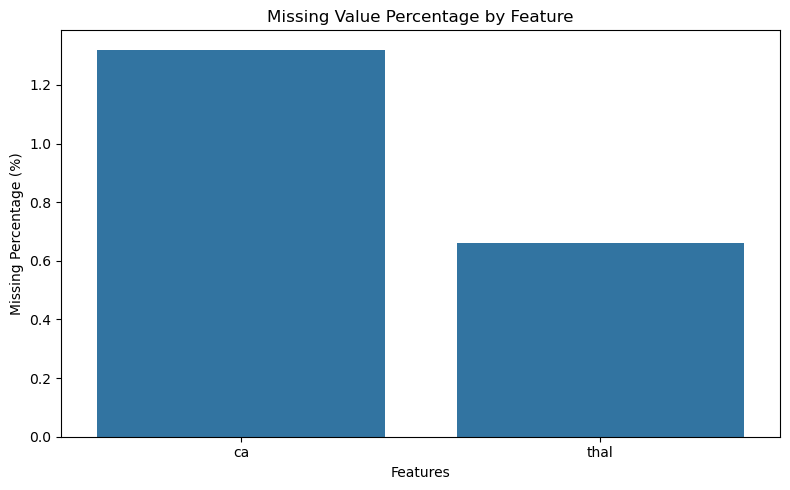


TOTAL MISSING VALUES
Total Missing Values : 6


In [23]:
# =============================================================================
# STEP 2: MISSING VALUE ANALYSIS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("MISSING VALUE COUNT")
print("=" * 70)

missing_count = df.isnull().sum()

display(
    missing_count.to_frame(name="Missing Values")
)


print("\n" + "=" * 70)
print("MISSING VALUE PERCENTAGE")
print("=" * 70)

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
})

display(missing_summary)


print("\n" + "=" * 70)
print("FEATURES WITH MISSING VALUES")
print("=" * 70)

missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_features) > 0:
    display(missing_features)
else:
    print("No missing values found in the dataset")


print("\n" + "=" * 70)
print("MISSING VALUE VISUALIZATION")
print("=" * 70)

missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing Percentage (%)"]
    )

    plt.xlabel("Features")
    plt.ylabel("Missing Percentage (%)")
    plt.title("Missing Value Percentage by Feature")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values to visualize")


print("\n" + "=" * 70)
print("TOTAL MISSING VALUES")
print("=" * 70)

total_missing = df.isnull().sum().sum()

print(f"Total Missing Values : {total_missing}")

In [24]:
# =============================================================================
# STEP 3: DUPLICATE ANALYSIS
# =============================================================================


print("=" * 70)
print("TOTAL DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")


print("\n" + "=" * 70)
print("DUPLICATE PERCENTAGE")
print("=" * 70)

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")


print("\n" + "=" * 70)
print("DUPLICATE RECORDS PREVIEW")
print("=" * 70)

if duplicate_count > 0:
    
    duplicate_rows = df[df.duplicated(keep=False)]
    
    display(duplicate_rows.head())
    
else:
    print("No duplicate records found")


print("\n" + "=" * 70)
print("DATASET SIZE BEFORE DUPLICATE REMOVAL")
print("=" * 70)

print(f"Rows Before Removal : {df.shape[0]}")


print("\n" + "=" * 70)
print("DUPLICATE REMOVAL")
print("=" * 70)

# Create a copy for preprocessing
df_clean = df.drop_duplicates()

print(f"Rows After Removal : {df_clean.shape[0]}")


print("\n" + "=" * 70)
print("ROWS REMOVED")
print("=" * 70)

rows_removed = df.shape[0] - df_clean.shape[0]

print(f"Total Rows Removed : {rows_removed}")

TOTAL DUPLICATE RECORDS
Duplicate Rows : 0

DUPLICATE PERCENTAGE
Duplicate Percentage : 0.00%

DUPLICATE RECORDS PREVIEW
No duplicate records found

DATASET SIZE BEFORE DUPLICATE REMOVAL
Rows Before Removal : 303

DUPLICATE REMOVAL
Rows After Removal : 303

ROWS REMOVED
Total Rows Removed : 0


In [25]:
# =============================================================================
# STEP 4: UNIVARIATE ANALYSIS
# =============================================================================


# Use cleaned dataset after duplicate removal
df = df_clean.copy()


print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)


numerical_features = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

print(numerical_features)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 70)

display(df[numerical_features].describe().T)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE DISTRIBUTION")
print("=" * 70)



NUMERICAL FEATURES
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

NUMERICAL FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2



NUMERICAL FEATURE DISTRIBUTION


In [26]:
# =============================================================================
# CATEGORICAL FEATURE ANALYSIS
# =============================================================================

print("\n" + "=" * 70)
print("CATEGORICAL / BINARY FEATURES")
print("=" * 70)


categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


# Keep only columns present in dataset
categorical_features = [
    col for col in categorical_features
    if col in df.columns
]


print("Categorical Features:")
print(categorical_features)


print("\n" + "=" * 70)
print("CATEGORICAL FEATURE DISTRIBUTION")
print("=" * 70)


for feature in categorical_features:

    print(f"\n--- {feature} ---")

    display(
        df[feature]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame(name="Count")
    )


CATEGORICAL / BINARY FEATURES
Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

CATEGORICAL FEATURE DISTRIBUTION

--- sex ---


,Count
sex,
0.0,97
1.0,206



--- cp ---


,Count
cp,
1.0,23
2.0,50
3.0,86
4.0,144



--- fbs ---


...

,Count
slope,
1.0,142
2.0,140
3.0,21



--- ca ---


,Count
ca,
0.0,176
1.0,65
2.0,38
3.0,20
NaN,4



--- thal ---


,Count
thal,
3.0,166
6.0,18
7.0,117
NaN,2


In [27]:
# =============================================================================
# STEP 5: OUTLIER ANALYSIS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("NUMERICAL FEATURES FOR OUTLIER ANALYSIS")
print("=" * 70)


# Select continuous numerical variables
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]


# Keep only available columns
numerical_features = [
    col for col in numerical_features
    if col in df.columns
]


print(numerical_features)


print("\n" + "=" * 70)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 70)


outlier_summary = []


for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_limit, 2),
        "Upper Bound": round(upper_limit, 2),
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage, 2)
    })


outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

NUMERICAL FEATURES FOR OUTLIER ANALYSIS
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

OUTLIER DETECTION USING IQR METHOD


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,age,28.50,80.50,0,0.00
1,trestbps,90.00,170.00,9,2.97
2,chol,115.00,371.00,5,1.65
3,thalach,84.75,214.75,1,0.33
4,oldpeak,-2.40,4.00,5,1.65



BOXPLOT VISUALIZATION


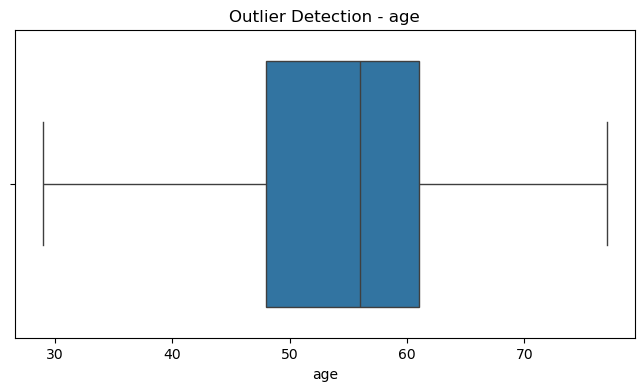

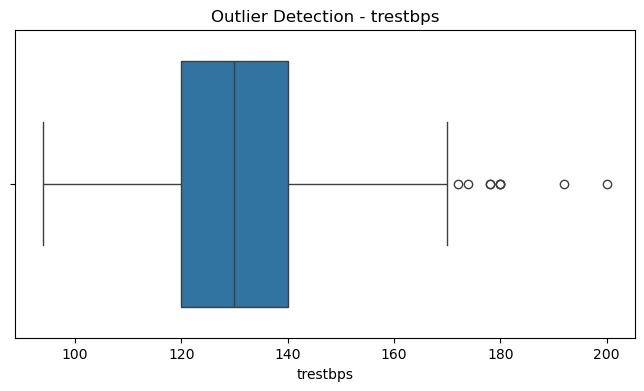

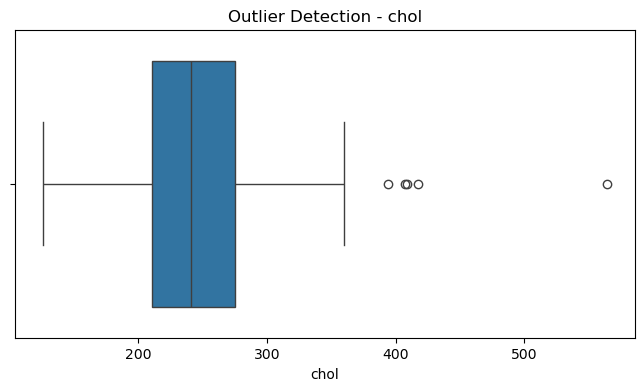

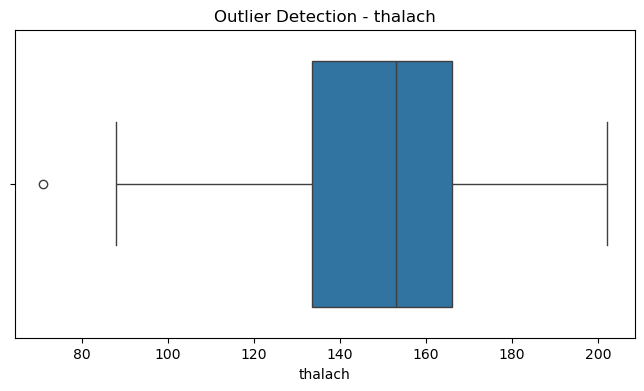

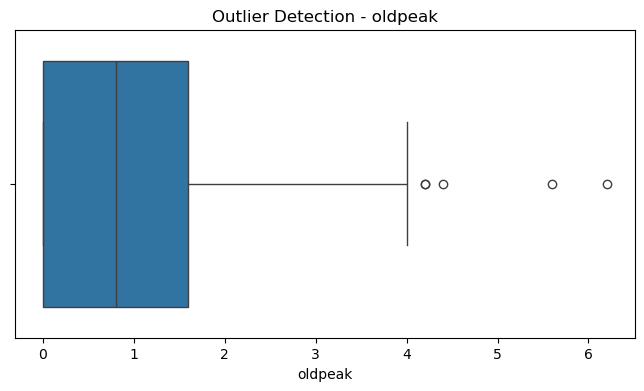

In [28]:
print("\n" + "=" * 70)
print("BOXPLOT VISUALIZATION")
print("=" * 70)


for feature in numerical_features:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[feature]
    )
    
    plt.title(f"Outlier Detection - {feature}")
    plt.xlabel(feature)
    plt.show()


OUTLIER PERCENTAGE VISUALIZATION


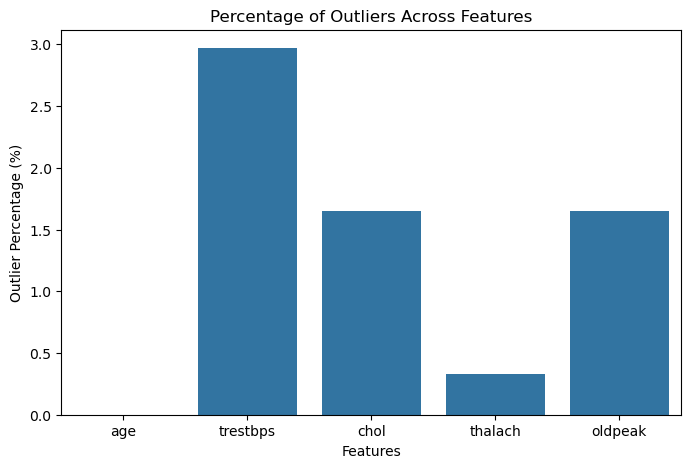

In [29]:
print("\n" + "=" * 70)
print("OUTLIER PERCENTAGE VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(8,5))


sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier Percentage (%)"
)


plt.title("Percentage of Outliers Across Features")
plt.xlabel("Features")
plt.ylabel("Outlier Percentage (%)")
plt.show()

In [ ]:
# =============================================================================
# STEP 6A: BINARY TARGET CONVERSION
# =============================================================================

print("=" * 70)
print("CONVERTING TARGET TO BINARY CLASSIFICATION")
print("=" * 70)

# Original target:
# 0 = No heart disease
# 1, 2, 3, 4 = Heart disease

df["target"] = (df["target"] > 0).astype(int)

print("\nBinary Target Mapping:")
print("0 = No Heart Disease")
print("1 = Heart Disease")


print("\n" + "=" * 70)
print("BINARY TARGET DISTRIBUTION")
print("=" * 70)

binary_distribution = pd.DataFrame({
    "Class Count": df["target"].value_counts().sort_index(),
    "Percentage (%)": (
        df["target"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

display(binary_distribution)

CONVERTING TARGET TO BINARY CLASSIFICATION

Binary Target Mapping:
0 = No Heart Disease
1 = Heart Disease

BINARY TARGET DISTRIBUTION


,Class Count,Percentage (%)
target,,
0,164,54.13
1,139,45.87


TARGET VARIABLE DISTRIBUTION
target
0    164
1    139
Name: count, dtype: int64

CLASS DISTRIBUTION PERCENTAGE


,Class Count,Percentage (%)
target,,
0,164,54.13
1,139,45.87



CLASS LABEL MAPPING
Class 0 : 164 samples
Class 1 : 139 samples

CLASS DISTRIBUTION VISUALIZATION


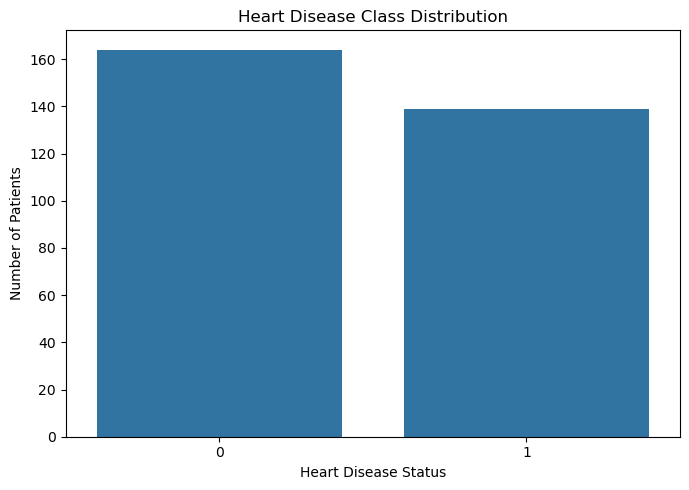


CLASS BALANCE RATIO
Minority/Majority Class Ratio : 0.848


In [31]:
# =============================================================================
# STEP 6B: CLASS DISTRIBUTION ANALYSIS
# =============================================================================

print("=" * 70)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 70)


target_column = "target"


print(df[target_column].value_counts())


print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PERCENTAGE")
print("=" * 70)

class_distribution = pd.DataFrame({
    "Class Count": df[target_column].value_counts(),
    "Percentage (%)": (
        df[target_column]
        .value_counts(normalize=True) * 100
    ).round(2)
})


display(class_distribution)


print("\n" + "=" * 70)
print("CLASS LABEL MAPPING")
print("=" * 70)


for label, count in df[target_column].value_counts().sort_index().items():

    print(f"Class {label} : {count} samples")


print("\n" + "=" * 70)
print("CLASS DISTRIBUTION VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(7, 5))


sns.countplot(
    data=df,
    x=target_column
)


plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("CLASS BALANCE RATIO")
print("=" * 70)


class_ratio = (
    df[target_column]
    .value_counts()
    .min()
    /
    df[target_column]
    .value_counts()
    .max()
)


print(f"Minority/Majority Class Ratio : {class_ratio:.3f}")

In [32]:
# =============================================================================
# STEP 7: CORRELATION ANALYSIS
# =============================================================================


import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)


# Calculate correlation
correlation_matrix = df.corr()


display(correlation_matrix.round(2))

CORRELATION MATRIX


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.42



CORRELATION HEATMAP


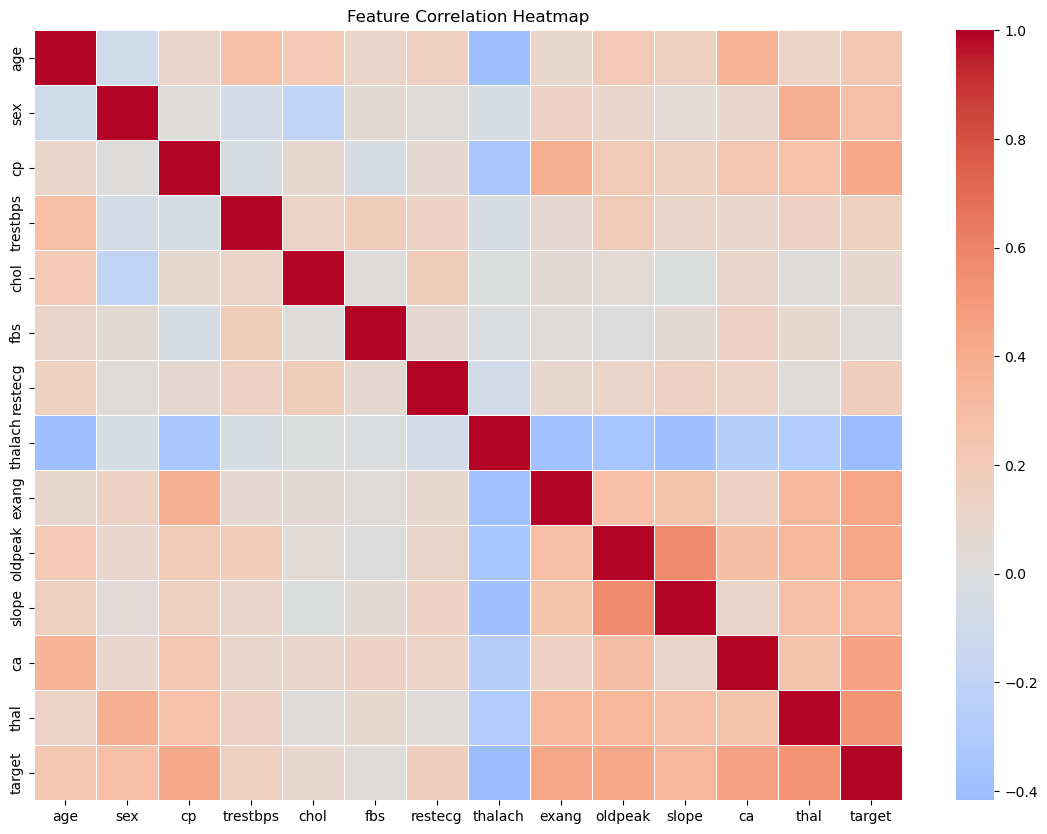

In [33]:
print("\n" + "=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)


plt.figure(figsize=(14,10))


sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)


plt.title("Feature Correlation Heatmap")
plt.show()

In [34]:
# =============================================================================
# STEP 8: RELATIONSHIP WITH TARGET VARIABLE
# =============================================================================

print("=" * 70)
print("TARGET VARIABLE RELATIONSHIP ANALYSIS")
print("=" * 70)


target_column = "target"


# -----------------------------------------------------------------------------
# Separate numerical and categorical/binary features
# -----------------------------------------------------------------------------

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Keep only features that actually exist in the dataset
numerical_features = [
    col for col in numerical_features
    if col in df.columns
]


categorical_features = [
    col for col in df.columns
    if col not in numerical_features + [target_column]
]


# -----------------------------------------------------------------------------
# Display feature groups
# -----------------------------------------------------------------------------

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical/Binary Features:")
print(categorical_features)

TARGET VARIABLE RELATIONSHIP ANALYSIS

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical/Binary Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [35]:
print("\n" + "=" * 70)
print("NUMERICAL FEATURES BY HEART DISEASE STATUS")
print("=" * 70)


for feature in numerical_features:
    
    print("\n")
    print("-"*60)
    print(feature)
    print("-"*60)
    
    display(
        df.groupby(target_column)[feature]
        .describe()
    )


NUMERICAL FEATURES BY HEART DISEASE STATUS


------------------------------------------------------------
age
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,52.585366,9.511957,29.0,44.75,52.0,59.0,76.0
1,139.0,56.625899,7.938416,35.0,52.00,58.0,62.0,77.0




------------------------------------------------------------
trestbps
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,129.250000,16.204739,94.0,120.0,130.0,140.0,180.0
1,139.0,134.568345,18.769019,100.0,120.0,130.0,145.0,200.0




------------------------------------------------------------
chol
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,242.640244,53.456580,126.0,208.75,234.5,267.25,564.0
1,139.0,251.474820,49.486835,131.0,217.50,249.0,283.50,409.0




------------------------------------------------------------
thalach
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,158.378049,19.199080,96.0,148.75,161.0,172.0,202.0
1,139.0,139.258993,22.593233,71.0,125.00,142.0,156.5,195.0




------------------------------------------------------------
oldpeak
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,0.586585,0.781734,0.0,0.00,0.2,1.025,4.2
1,139.0,1.574101,1.302580,0.0,0.55,1.4,2.500,6.2


NUMERICAL FEATURES VS HEART DISEASE STATUS


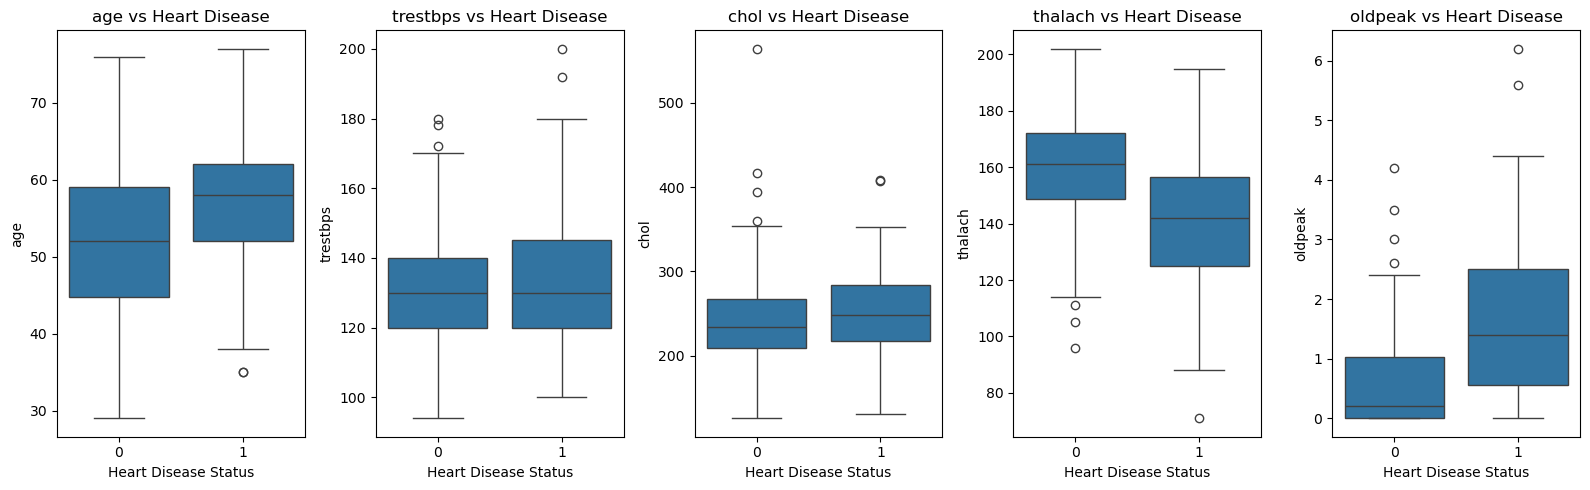

In [36]:
# =============================================================================
# NUMERICAL FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================

print("=" * 70)
print("NUMERICAL FEATURES VS HEART DISEASE STATUS")
print("=" * 70)


fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numerical_features),
    figsize=(16, 5)
)


for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs Heart Disease"
    )

    axes[i].set_xlabel("Heart Disease Status")
    axes[i].set_ylabel(feature)


plt.tight_layout()
plt.show()

CATEGORICAL FEATURES VS HEART DISEASE STATUS


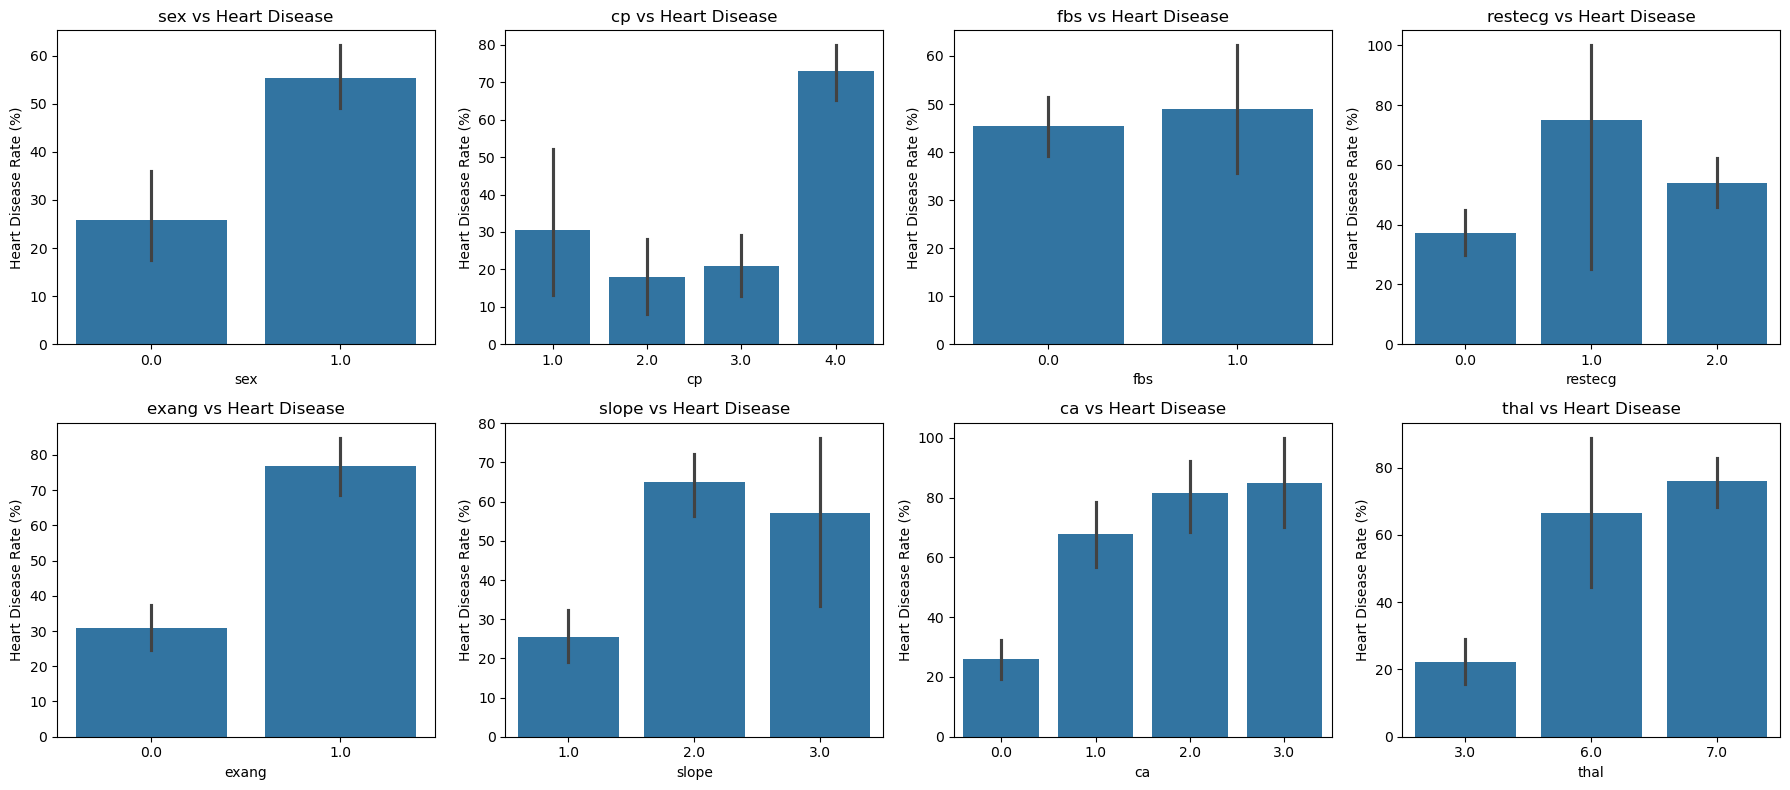

In [37]:
# =============================================================================
# CATEGORICAL FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================

print("=" * 70)
print("CATEGORICAL FEATURES VS HEART DISEASE STATUS")
print("=" * 70)


categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

n_features = len(categorical_features)

cols = 4
rows = (n_features + cols - 1) // cols


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, rows * 4)
)


axes = axes.flatten()


for i, feature in enumerate(categorical_features):

    sns.barplot(
        data=df,
        x=feature,
        y=target_column,
        ax=axes[i],
        estimator=lambda x: x.mean() * 100
    )

    axes[i].set_title(
        f"{feature} vs Heart Disease"
    )

    axes[i].set_ylabel(
        "Heart Disease Rate (%)"
    )

    axes[i].set_xlabel(
        feature
    )


# Remove unused plots
for j in range(i + 1, len(axes)):
    axes[j].remove()


plt.tight_layout()
plt.show()

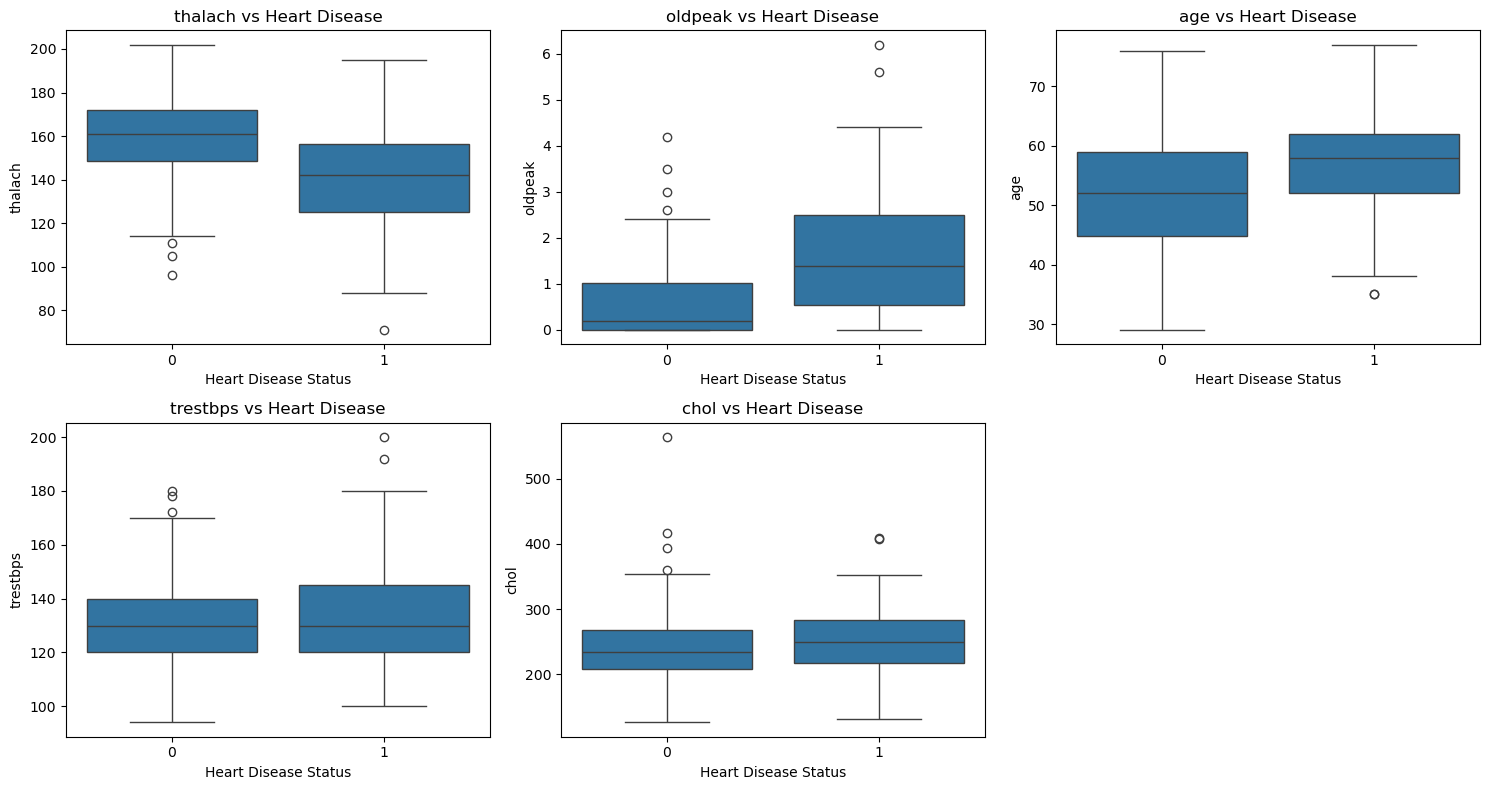

In [38]:
# =============================================================================
# TOP NUMERICAL FEATURES VS TARGET (COMBINED)
# =============================================================================

top_numerical_features = [
    "thalach",
    "oldpeak",
    "age",
    "trestbps",
    "chol"
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)


axes = axes.flatten()


for i, feature in enumerate(top_numerical_features):

    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs Heart Disease"
    )

    axes[i].set_xlabel("Heart Disease Status")
    axes[i].set_ylabel(feature)


# Remove unused sixth plot
axes[-1].remove()


plt.tight_layout()
plt.show()

In [39]:
# =============================================================================
# STEP 9: EDA SUMMARY
# =============================================================================

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)


# -----------------------------------------------------------------------------
# Calculate key EDA statistics
# -----------------------------------------------------------------------------

target_distribution = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index() * 100
)

correlation_with_target = (
    df.corr(numeric_only=True)[target_column]
    .drop(target_column)
)

highest_positive_feature = correlation_with_target.idxmax()
highest_positive_value = correlation_with_target.max()

highest_negative_feature = correlation_with_target.idxmin()
highest_negative_value = correlation_with_target.min()


# -----------------------------------------------------------------------------
# Outlier features
# -----------------------------------------------------------------------------

outlier_summary = {}

for feature in numerical_features:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    outlier_summary[feature] = len(outliers)


major_outlier_features = [
    f"{feature} ({count} records)"
    for feature, count in outlier_summary.items()
    if count > 0
]


# -----------------------------------------------------------------------------
# EDA Summary Table
# -----------------------------------------------------------------------------

eda_summary = pd.DataFrame({
    "EDA Component": [
        "Dataset Size",
        "Features",
        "Missing Values",
        "Duplicate Records",
        "Target Variable",
        "Class Distribution",
        "Highest Positive Correlation",
        "Highest Negative Correlation",
        "Major Outlier Features"
    ],
    
    "Findings": [
        f"{df.shape[0]} rows and {df.shape[1]} columns",
        
        ", ".join(df.columns),
        
        f"{df.isnull().sum().sum()} missing values detected "
        f"(ca: {df['ca'].isnull().sum()}, thal: {df['thal'].isnull().sum()})",
        
        f"{duplicate_count} duplicate rows",
        
        f"{target_column} "
        "(0 = No Heart Disease, 1 = Heart Disease)",
        
        (
            f"Class 0: {target_distribution[0]:.2f}%, "
            f"Class 1: {target_distribution[1]:.2f}%"
        ),
        
        (
            f"{highest_positive_feature} "
            f"({highest_positive_value:.2f})"
        ),
        
        (
            f"{highest_negative_feature} "
            f"({highest_negative_value:.2f})"
        ),
        
        ", ".join(major_outlier_features)
    ]
})


display(eda_summary)

EXPLORATORY DATA ANALYSIS SUMMARY


,EDA Component,Findings
0,Dataset Size,303 rows and 14 columns
1,Features,"age, sex, cp, trestbps, chol, fbs, restecg, th..."
2,Missing Values,"6 missing values detected (ca: 4, thal: 2)"
3,Duplicate Records,0 duplicate rows
4,Target Variable,"target (0 = No Heart Disease, 1 = Heart Disease)"
5,Class Distribution,"Class 0: 54.13%, Class 1: 45.87%"
6,Highest Positive Correlation,thal (0.53)
7,Highest Negative Correlation,thalach (-0.42)
8,Major Outlier Features,"trestbps (9 records), chol (5 records), thalac..."


In [48]:
# =============================================================================
# STEP 10: SAVE CLEANED DATASET
# =============================================================================

import os


# Save cleaned dataset
df_clean.to_csv(
    "../../../data/processed/heartdisease_cleaned.csv",
    index=False
)


print("Cleaned dataset saved successfully")

print("\nSaved File:")
print("data/processed/heartdisease_cleaned.csv")

print("\nDataset Shape:")
print(df_clean.shape)


Cleaned dataset saved successfully

Saved File:
data/processed/heartdisease_cleaned.csv

Dataset Shape:
(303, 14)
